## 문제정의

**질문(Pain Point)**
이 회사(dunnhumby 데이터의 그로서리 리테일러)는 캠페인 타겟팅을 이미 활동량이 많은 헤비유저 위주로 하고 있는데, 이 전략이 최선인가? 아니면 놓치고 있는 매출 기회가 있는가?

**목적(Action)** 현재 타겟팅 전략의 강점과 약점을 진단하고, 데이터 근거로 뒷받침되는 개선 방향(타겟팅 확대 대상 및 예상 임팩트)을 제안한다.

## 성공지표(Metric)

- 대상/비대상 그룹의 캠페인 이전 활동량 차이가 실제로 유의미한가
- 활동량뿐 아니라 최근성·객단가까지 고려했을 때, 회사의 실제 타겟팅 기준을 데이터로 추정할 수 있는가
- 그 기준을 적용했을 때 놓친 가구가 얼마나 되는가
- 그 매출 격차가 통계적으로 유의미하고, 놓친 매출 규모는 구체적으로 얼마인가
- 놓친 가구들의 실제 구매 패턴을 근거로, 구체적으로 어떤 액션을 제안할 수 있는가

## 데이터셋

dunnhumby - The Complete Journey (Kaggle 공개)

- 미국의 특정(비공개) 대형 그로서리 체인, 2,500가구, 2016-2018년 2년치
- transaction_data 약 259만 건 실거래 확인됨 (feasibility check 완료, PASS)
- 사용 테이블: transaction_data, campaign_table, campaign_desc, coupon, coupon_redempt, product
- 한계: 미국 데이터라 한국 수치와 직접 비교 불가 / 원가정보 없어 매출·할인액 기준으로만 분석 / 구독 멤버십 데이터 없음 / 타겟팅이 무작위 배정이 아니므로 인과관계 증명 불가(상관관계만)

## 가설목록

**H1. 타겟팅은 무작위가 아니다** 캠페인 대상 가구는 무작위로 뽑힌 게 아니라 이미 활동량이 많은 헤비유저 위주로 선정됐을 것이다. → 검증: 대상/비대상 그룹의 캠페인 이전 활동량 비교. **채택.** (t=25.70, p<0.0001)

**H2. 회사는 활동량 외에 최근성·객단가까지 고려한 기준으로 타겟팅했을 것이다** 같은 활동량 구간 안에서도 최근성·객단가가 다르다면, 활동량만으로는 타겟팅 기준을 설명할 수 없다. → 검증: RFM 점수화 후 대상 가구 분포 분석. **채택.** 핵심 우량고객 트랙(RFM 총점≥9)과 win-back 트랙(저최근성+구매횟수≥19회+객단가≥27.66달러), 두 가지 기준으로 운영된 것으로 추정됨

**H3. 이 기준을 비대상 가구에 적용하면 실제로 놓친 가구가 존재할 것이다** → 검증: H2에서 정의한 두 기준을 비대상 가구에 적용. **채택.** 핵심 71가구 + win-back 7가구, 총 78가구

**H4. 이 gap은 통계적으로 유의미하며, 실제 매출 임팩트로 환산 가능하다** → 검증: t-검정(핵심 t=3.37·p=0.0012, win-back t=3.97·p=0.0012) + 매출 임팩트 계산. **채택.** 488일 기준 총 85,992달러(전체 매출의 1.4%)

※ 놓친 78가구에 대한 구체적 액션 제안은 가설 검증이 아닌 실무 제안이므로 별도 "액션 도출" 섹션에서 다룸 — 핵심그룹(청소·위생/간편식)은 6달러 이상 구매 시 2달러 할인, win-back그룹(신선식품/가정용품)은 조건 없이 2.5달러 할인 제안

**한계(별도 명시, 가설 아님)** 이 상관관계를 인과관계로 단정할 수 없다 — 관찰연구이므로 RFM 외 미관측 변수의 영향 가능성을 배제할 수 없음. 회사의 정확한 타겟팅 알고리즘도 알 수 없어, 두 트랙 정의는 데이터 기반 최선의 근사치임. win-back 그룹은 표본이 7가구로 작아 추정치 안정성이 낮음. 액션 도출 섹션의 카테고리 선호는 상관관계 기반 관찰이며 실제 프로모션 반응은 검증되지 않음.

## 기대결과

- 회사의 실제 타겟팅 기준을 RFM 관점에서 데이터 기반으로 추정 (핵심그룹/win-back 두 트랙)
- 이 기준을 놓친 가구를 구체적으로 식별 (핵심 71가구 + win-back 7가구, 총 78가구)
- 통계적 유의성 검증을 거친 신뢰할 수 있는 매출 임팩트 추정치 제시 (85,992달러, 488일 기준, 전체 매출의 1.4%)
- 놓친 가구의 실제 구매 카테고리를 분석해 그룹별 구체적 액션(핵심그룹 캠페인 편입, win-back 무조건 할인 DM) 제안
- 인과관계 한계를 포함해 데이터 근거로 뒷받침되는 결론 제시

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

VOID = "#030303"; SIGNAL = "#C2FF00"; PAPER = "#F2F2EA"
plt.rcParams["figure.facecolor"] = PAPER
plt.rcParams["axes.facecolor"] = PAPER
plt.rcParams["axes.edgecolor"] = VOID
plt.rcParams["axes.labelcolor"] = VOID
plt.rcParams["text.color"] = VOID
plt.rcParams["xtick.color"] = VOID
plt.rcParams["ytick.color"] = VOID
plt.rcParams["axes.titlecolor"] = VOID

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/dunnhumby"

Mounted at /content/drive


## 현황 파악

데이터셋 구조, 캠페인 규모, 캠페인 시작 시점, 캠페인 전후 쿠폰 적용 거래 비율을 SQL 쿼리로 확인한다.

In [2]:
# 목적: 1단계 현황파악에 필요한 4개 테이블을 불러오고, SQL 쿼리 실행 환경(duckdb)을 준비한다
transaction_data = pd.read_csv(f"{DATA_DIR}/transaction_data.csv")   # 거래 원장
campaign_table = pd.read_csv(f"{DATA_DIR}/campaign_table.csv")       # 가구별 캠페인 대상 여부
campaign_desc = pd.read_csv(f"{DATA_DIR}/campaign_desc.csv")         # 캠페인 타입/기간 정보
coupon = pd.read_csv(f"{DATA_DIR}/coupon.csv")                       # 캠페인별 발급 쿠폰 정보

!pip install duckdb -q
import duckdb   # pandas DataFrame에 SQL 쿼리를 바로 실행하기 위한 라이브러리

In [3]:
# 목적: transaction_data 전체 행 수와 가구 수를 확인해 데이터 규모를 파악한다
duckdb.sql("""
    SELECT
        COUNT(*) AS row_count,                          -- 전체 거래 행 수
        COUNT(DISTINCT household_key) AS household_count -- 고유 가구 수
    FROM transaction_data
""").df()

,row_count,household_count
0,2595732,2500


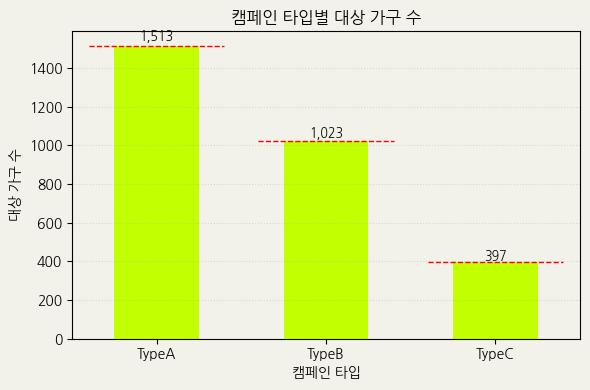

In [4]:
# 목적: 캠페인 타입별 대상 가구 수를 막대그래프로 시각화 — 정확한 값을 읽기 쉽게 눈금/라벨 추가
campaign_summary = duckdb.sql("""
    SELECT
        d.DESCRIPTION AS campaign_type,
        COUNT(DISTINCT c.household_key) AS household_count
    FROM campaign_table c
    JOIN campaign_desc d ON c.CAMPAIGN = d.CAMPAIGN
    GROUP BY d.DESCRIPTION
    ORDER BY household_count DESC
""").df()

ax = campaign_summary.plot(kind="bar", x="campaign_type", y="household_count", legend=False, color=SIGNAL, figsize=(6,4))
ax.set_title("캠페인 타입별 대상 가구 수")
ax.set_xlabel("캠페인 타입")
ax.set_ylabel("대상 가구 수")

# 막대마다 정확한 값을 빨간 점선 + 숫자 라벨로 표시
for i, v in enumerate(campaign_summary["household_count"]):
    ax.hlines(v, i-0.4, i+0.4, colors="red", linestyles="dashed", linewidth=1)   #막대 높이에 맞춰 빨간 점선
    ax.text(i, v + v*0.02, f"{v:,}", ha="center", fontsize=9, color=VOID)        #막대 위에 정확한 숫자

ax.yaxis.set_major_locator(plt.MaxNLocator(10))  # y축 눈금 촘촘하게
ax.grid(axis="y", linestyle=":", alpha=0.4)      # 가로 그리드선 추가

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 결과 해석
- TypeA가 대상 가구 수 가장 많음(1,513가구), TypeB(1,023가구), TypeC(397가구) 순
- 가구 수 기준으로는 TypeA가 압도적으로 큰 캠페인 그룹

### 다음 단계
- 캠페인 타입별로 캠페인이 몇 개씩 진행됐는지 확인

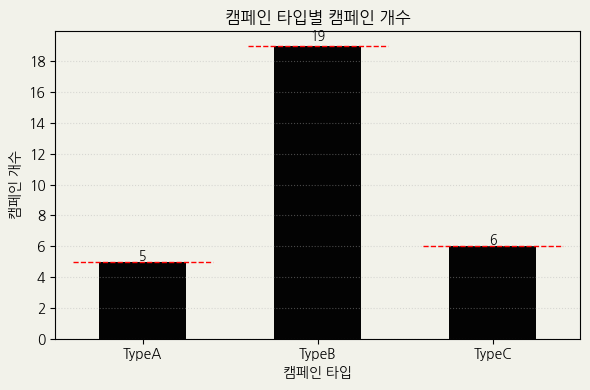

In [5]:
# 목적: 캠페인 타입별로 캠페인이 몇 개씩 진행됐는지 막대그래프로 확인한다
campaign_summary = duckdb.sql("""
    SELECT
        d.DESCRIPTION AS campaign_type,                     -- 캠페인 타입 (TypeA/B/C)
        COUNT(DISTINCT c.CAMPAIGN) AS campaign_count,        -- 해당 타입의 캠페인 개수
        COUNT(DISTINCT c.household_key) AS household_count  -- 해당 타입에 노출된 가구 수
    FROM campaign_table c
    JOIN campaign_desc d ON c.CAMPAIGN = d.CAMPAIGN
    GROUP BY d.DESCRIPTION
    ORDER BY household_count DESC
""").df()

ax = campaign_summary.plot(kind="bar", x="campaign_type", y="campaign_count", legend=False, color=VOID, figsize=(6,4))
ax.set_title("캠페인 타입별 캠페인 개수")
ax.set_xlabel("캠페인 타입")
ax.set_ylabel("캠페인 개수")

for i, v in enumerate(campaign_summary["campaign_count"]):
    ax.hlines(v, i-0.4, i+0.4, colors="red", linestyles="dashed", linewidth=1)  # 막대 높이에 맞춰 빨간 점선
    ax.text(i, v + v*0.02, f"{v:,}", ha="center", fontsize=9, color=VOID)       # 막대 위에 정확한 숫자

ax.yaxis.set_major_locator(plt.MaxNLocator(10))  # y축 눈금 촘촘하게
ax.grid(axis="y", linestyle=":", alpha=0.4)      # 가로 그리드선 추가

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 결과 해석
- TypeB는 캠페인 개수 19개로 가장 많지만, 대상 가구 수는 1,023가구로 TypeA(1,513가구)보다 적음
- 캠페인 1개당 평균 가구 수: TypeA 약 303가구, TypeB 약 54가구, TypeC 약 66가구
- TypeA는 소수 캠페인으로 넓은 대상, TypeB는 다수 캠페인으로 좁은 대상에 반복 운영되는 방식,TypeC는 대상 가구수도 작고 캠페인당 가구 수도 작은편(소수 마케팅)으로 보임 (패턴 후보)
- 왜 이런 차이가 나는지는 campaign_desc 세부 정보로 추가 확인 필요

### 다음 단계
- 캠페인 타입별 규모(개수/가구 수) 확인 완료
- 다음은 캠페인이 실제로 언제 진행됐는지(시작/종료 시점) 확인해 사전/사후 비교 기준일을 잡는다

In [6]:
# 목적: 캠페인이 언제 시작해서 언제 끝났는지 확인한다
campaign_timing = duckdb.sql("""
    SELECT MIN(START_DAY) AS first_campaign_day, MAX(END_DAY) AS last_campaign_day
    FROM campaign_desc
""").df()

campaign_timing.rename(columns={
    "first_campaign_day": "첫캠페인시작일",
    "last_campaign_day": "마지막캠페인종료일"
})

,첫캠페인시작일,마지막캠페인종료일
0,224,719


### 결과 해석
- 캠페인은 224일차부터 719일차까지 진행됨
- 특이사항: 캠페인 종료일(719일)이 transaction_data의 마지막 관측일(711일)보다 늦음 — 일부 캠페인은 데이터에 기록된 실제 거래 기간 밖까지 종료일이 잡혀있다는 뜻, 사후 매출 계산 시 관측 가능한 마지막 날짜(711일) 기준으로 기간을 잡아 한다

### 다음 단계
- 캠페인 시작일(224일)을 기준으로 캠페인 전/후 쿠폰 적용 거래 비율을 비교한다

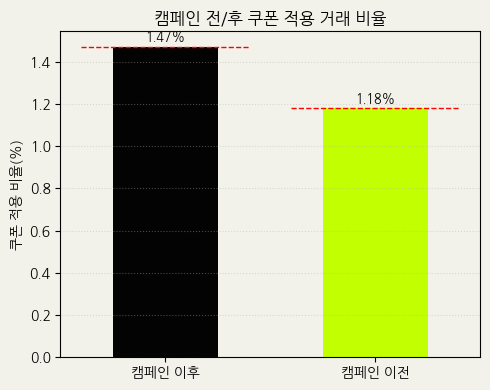

In [7]:
# 목적: 캠페인 전/후 쿠폰 적용 거래 비율 차이를 막대그래프로 시각화한다
CAMPAIGN_START_DAY = 224

coupon_rate = duckdb.sql(f"""
    SELECT
        CASE WHEN DAY < {CAMPAIGN_START_DAY} THEN '캠페인 이전' ELSE '캠페인 이후' END AS period,
        ROUND(100.0 * SUM(CASE WHEN COUPON_DISC <> 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS coupon_rate_pct
    FROM transaction_data
    GROUP BY period
""").df()

ax = coupon_rate.plot(kind="bar", x="period", y="coupon_rate_pct", legend=False, color=[VOID, SIGNAL], figsize=(5,4))
ax.set_title("캠페인 전/후 쿠폰 적용 거래 비율")
ax.set_xlabel("")
ax.set_ylabel("쿠폰 적용 비율(%)")

for i, v in enumerate(coupon_rate["coupon_rate_pct"]):
    ax.hlines(v, i-0.4, i+0.4, colors="red", linestyles="dashed", linewidth=1)  # 막대 높이에 맞춰 빨간 점선
    ax.text(i, v + v*0.02, f"{v:.2f}%", ha="center", fontsize=9, color=VOID)    # 막대 위에 정확한 숫자

ax.yaxis.set_major_locator(plt.MaxNLocator(10))  # y축 눈금 촘촘하게
ax.grid(axis="y", linestyle=":", alpha=0.4)      # 가로 그리드선 추가

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 결과 해석
- 캠페인 이후 쿠폰 적용 거래 비율이 1.18% → 1.47%로 증가 (+0.29%p, 마케팅 전 대비 약 25% 상대 증가)
- %p 절대 변화량과 상대 증가율을 함께 표기 — 비율만 보면 작아 보이고, 상대 증가율만 보면 기저값이 작다는 맥락이 사라지므로 둘 다 필요
- 다만 이건 거래 라인 단위 비율이라 절대값 자체는 작게 보임 — 장바구니(basket) 단위로 보면 쿠폰 사용 비중이 더 크게 나타날 수 있음 (라인 단위 vs 바스켓 단위 측정 스케일 차이, 기존 확인한 한계)

### 다음 단계
- 1단계 현황파악(데이터 규모, 캠페인 타입/규모, 캠페인 시점, 쿠폰 적용 비율) 시각화까지 완료
- 다음은 2단계로 넘어가서 캠페인 이전 활동량 기준으로 대상/비대상 가구를 비교해, 차이가 통계적으로 유의미한지 확인한다

## 2단계 — H1. 타겟팅은 무작위가 아니다

캠페인 이전 활동량을 기준으로, 캠페인 대상 가구와 비대상 가구의 활동량 차이가 통계적으로 유의미한지 확인한다.

In [8]:
# 목적: 가구별 캠페인 이전 구매 횟수·매출과 타겟팅 여부를 집계한다
pre_summary = duckdb.sql(f"""
    SELECT
        t.household_key,
        COUNT(DISTINCT t.BASKET_ID) AS pre_total_baskets,
        SUM(t.SALES_VALUE) AS pre_total_sales,
        CASE WHEN c.household_key IS NOT NULL THEN TRUE ELSE FALSE END AS ever_targeted
    FROM transaction_data t
    LEFT JOIN (SELECT DISTINCT household_key FROM campaign_table) c
        ON t.household_key = c.household_key
    WHERE t.DAY < {CAMPAIGN_START_DAY}
    GROUP BY t.household_key, ever_targeted
""").df()

pre_summary.head().rename(columns={
    "household_key": "가구ID",
    "pre_total_baskets": "구매횟수",
    "pre_total_sales": "매출",
    "ever_targeted": "타겟팅여부"
})

,가구ID,구매횟수,매출,타겟팅여부
0,1506,29,403.73,True
1,1590,70,2344.99,True
2,1048,35,535.89,True
3,1607,47,1120.93,True
4,1479,206,2121.12,True


### 결과 해석
- 가구별로 캠페인 이전 구매 활동과 타겟팅 여부가 잘 뽑힘

### 다음 단계
- 대상/비대상 그룹으로 나눠서 가구 수와 평균 활동량을 비교한다

In [9]:
# 목적: 대상/비대상 그룹의 캠페인 이전 활동량(평균 구매횟수·매출)을 비교한다
group_compare = duckdb.sql("""
    SELECT
        ever_targeted,
        COUNT(*) AS household_count,
        ROUND(AVG(pre_total_baskets), 2) AS avg_pre_baskets,
        ROUND(AVG(pre_total_sales), 2) AS avg_pre_sales
    FROM pre_summary
    GROUP BY ever_targeted
""").df()

group_compare.rename(columns={
    "ever_targeted": "타겟팅여부",
    "household_count": "가구수",
    "avg_pre_baskets": "평균구매횟수",
    "avg_pre_sales": "평균매출($)"
})

,타겟팅여부,가구수,평균구매횟수,평균매출($)
0,False,913,11.35,265.72
1,True,1583,37.63,1049.56


### 결과 해석
- 캠페인 대상이었던 가구(1,583가구)는 캠페인 이전에도 평균 구매 37.63회, 매출 1,049.56달러로 훨씬 활발했음
- 비대상 가구(913가구)는 평균 구매 11.35회, 매출 265.72달러로 대상 가구의 1/4 수준
- 캠페인 대상 선정이 무작위가 아니라 원래 활동량이 많은 가구 위주로 이뤄졌을 가능성이 큼 (아직 패턴 후보)
- 다만 1,583+913=2,496가구로, 전체 2,500가구 중 4가구가 이 비교에서 빠져있음

### 다음 단계
- 그래프로 보기 전에, 빠진 4가구가 왜 빠졌는지부터 확인한다

In [10]:
# 목적: 사전 활동량 집계에서 빠진 가구가 왜 빠졌는지 확인한다
missing_households = duckdb.sql("""
    SELECT DISTINCT household_key
    FROM transaction_data
    WHERE household_key NOT IN (SELECT household_key FROM pre_summary)
""").df()
print(f"빠진 가구 수: {len(missing_households)}")

missing_detail = duckdb.sql("""
    SELECT household_key, MIN(DAY) AS first_purchase_day
    FROM transaction_data
    WHERE household_key IN (SELECT household_key FROM missing_households)
    GROUP BY household_key
""").df()

missing_detail.rename(columns={
    "household_key": "가구ID",
    "first_purchase_day": "첫구매일"
})

빠진 가구 수: 4


,가구ID,첫구매일
0,1581,433
1,1077,277
2,1984,613
3,2325,671


### 결과 해석
- 빠진 4가구 모두 첫 구매일이 224일 이후(277/433/613/671일) — 캠페인 시작 전엔 거래 기록이 아예 없던 가구
- 편향이나 오류가 아니라, 캠페인 이전 활동량 자체가 존재하지 않아 비교 대상이 될 수 없는 가구였음 — 표본 제외 영향 확인 완료

### 다음 단계
- 확인된 2,496가구를 기준으로, 대상/비대상 그룹 차이를 그래프로 보고 통계적으로 유의미한지 검정한다

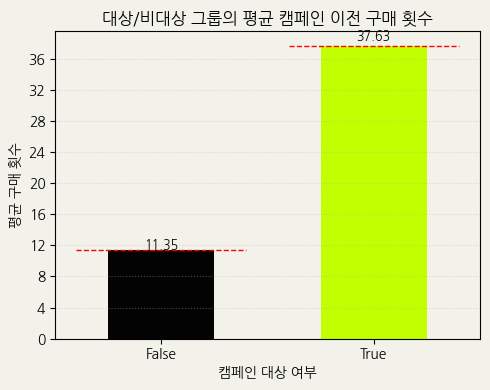

In [11]:
# 목적: 대상/비대상 그룹의 평균 캠페인 이전 구매 횟수 차이를 막대그래프로 시각화한다
group_summary = duckdb.sql("""
    SELECT
        ever_targeted,
        ROUND(AVG(pre_total_baskets), 2) AS avg_pre_baskets
    FROM pre_summary
    GROUP BY ever_targeted
""").df()

ax = group_summary.plot(kind="bar", x="ever_targeted", y="avg_pre_baskets", legend=False, color=[VOID, SIGNAL], figsize=(5,4))
ax.set_title("대상/비대상 그룹의 평균 캠페인 이전 구매 횟수")
ax.set_xlabel("캠페인 대상 여부")
ax.set_ylabel("평균 구매 횟수")

for i, v in enumerate(group_summary["avg_pre_baskets"]):
    ax.hlines(v, i-0.4, i+0.4, colors="red", linestyles="dashed", linewidth=1)  # 막대 높이에 맞춰 빨간 점선
    ax.text(i, v + v*0.02, f"{v:.2f}", ha="center", fontsize=9, color=VOID)     # 막대 위에 정확한 숫자

ax.yaxis.set_major_locator(plt.MaxNLocator(10))  # y축 눈금 촘촘하게
ax.grid(axis="y", linestyle=":", alpha=0.4)      # 가로 그리드선 추가

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 결과 해석
- 대상 가구(True)의 평균 캠페인 이전 구매 횟수가 비대상 가구(False)보다 압도적으로 높음 (37.63회 vs 11.35회, 약 3.3배)
- 그래프로 봐도 육안으로 명확한 차이지만, 우연이 아닌지는 별도 검정 필요

### 다음 단계
- 이 차이가 통계적으로 유의미한지 t-검정으로 확인한다

In [12]:
# 목적: 두 그룹의 평균 차이가 우연이 아니라 통계적으로 유의미한지 t-검정으로 확인한다
from scipy import stats

pre_summary_df = duckdb.sql("SELECT * FROM pre_summary").df()
targeted = pre_summary_df.loc[pre_summary_df["ever_targeted"] == True, "pre_total_baskets"]
untargeted = pre_summary_df.loc[pre_summary_df["ever_targeted"] == False, "pre_total_baskets"]

# Welch's t-test: 두 그룹의 분산이 같다고 가정하지 않는 t-검정 (더 안전한 기본 선택)
t_stat, p_value = stats.ttest_ind(targeted, untargeted, equal_var=False)
print(f"t-statistic: {t_stat:.2f}, p-value: {p_value:.10f}")

t-statistic: 25.70, p-value: 0.0000000000


### 결과 해석
- t-검정 결과 t=25.70, p<0.0001 — 대상/비대상 그룹의 활동량 차이는 통계적으로 매우 유의미함 (우연 아님)
- H1(타겟팅은 무작위가 아니다) 채택 확정

### 다음 단계
- 다음은 활동량 외에 최근성(Recency)·객단가(Monetary) 측면에서도 대상/비대상 가구 간 차이가 있는지 확인해, 타겟팅이 실제로 어떤 기준으로 이루어졌는지 파악한다

## H2. 회사는 어떤 기준으로 캠페인 타겟팅을 실행했는가?

- H1에서 타겟팅이 무작위가 아님을 통계적으로 확인함 (t=25.70, p<0.0001)
- 그렇다면 실제로 어떤 기준으로 대상을 선정했는지 구체적으로 추정해볼 필요가 있음
- 지금까지는 활동량(구매횟수) 기준으로만 봤는데, 최근성(Recency)·객단가(Monetary)까지 포함한 RFM 관점에서 재검증

In [21]:
# 목적: H2 섹션에 필요한 테이블(pre_summary~rfm_scored)을 원본 데이터부터 재생성한다
# Run All 시 이전 셀의 실행 상태/순서에 의존하지 않도록, 이 지점에서 필요한 걸 전부 새로 만듦
CAMPAIGN_START_DAY = 224
LAST_DAY = 711
PRE_DAYS = CAMPAIGN_START_DAY
POST_DAYS = LAST_DAY - CAMPAIGN_START_DAY + 1

# 캠페인 이전 가구별 구매 요약 + 타겟팅 여부
pre_summary = duckdb.sql(f"""
    SELECT t.household_key, COUNT(DISTINCT t.BASKET_ID) AS pre_total_baskets,
        SUM(t.SALES_VALUE) AS pre_total_sales,
        CASE WHEN c.household_key IS NOT NULL THEN TRUE ELSE FALSE END AS ever_targeted
    FROM transaction_data t
    LEFT JOIN (SELECT DISTINCT household_key FROM campaign_table) c
        ON t.household_key = c.household_key
    WHERE t.DAY < {CAMPAIGN_START_DAY}
    GROUP BY t.household_key, ever_targeted
""").df()

# 캠페인 이후 가구별 구매 요약
post_summary = duckdb.sql(f"""
    SELECT household_key, COUNT(DISTINCT BASKET_ID) AS post_total_baskets,
        SUM(SALES_VALUE) AS post_total_sales
    FROM transaction_data
    WHERE DAY >= {CAMPAIGN_START_DAY}
    GROUP BY household_key
""").df()

# 사전/사후 합치고 일평균 매출 증가분(daily_uplift) 계산
sim_data = duckdb.sql(f"""
    SELECT
        p.household_key,
        p.pre_total_baskets,
        p.ever_targeted,
        COALESCE(o.post_total_sales, 0) AS post_total_sales,
        p.pre_total_sales / {PRE_DAYS} AS pre_daily_sales,
        COALESCE(o.post_total_sales, 0) / {POST_DAYS} AS post_daily_sales,
        (COALESCE(o.post_total_sales, 0) / {POST_DAYS}) - (p.pre_total_sales / {PRE_DAYS}) AS daily_uplift
    FROM pre_summary p
    LEFT JOIN post_summary o ON p.household_key = o.household_key
""").df()

# 활동량(구매횟수) 사분위수 기준 4구간 분류
sim_data_tiered = duckdb.sql("""
    SELECT *, CASE
        WHEN pre_total_baskets <= 9 THEN '1. 9회 이하'
        WHEN pre_total_baskets <= 18 THEN '2. 10-18회'
        WHEN pre_total_baskets <= 35 THEN '3. 19-35회'
        ELSE '4. 36회 이상'
    END AS activity_tier
    FROM sim_data
""").df()

# RFM 원자료 (frequency=구매횟수, monetary=객단가, recency=캠페인 시작일 기준 마지막 구매 후 경과일)
rfm_raw = duckdb.sql(f"""
    SELECT p.household_key, p.ever_targeted, p.pre_total_baskets AS frequency,
        p.pre_total_sales / p.pre_total_baskets AS monetary,
        {CAMPAIGN_START_DAY} - r.last_purchase_day AS recency
    FROM pre_summary p
    JOIN (SELECT household_key, MAX(DAY) AS last_purchase_day
          FROM transaction_data WHERE DAY < {CAMPAIGN_START_DAY} GROUP BY household_key) r
        ON p.household_key = r.household_key
""").df()

# RFM 사분위 점수화 (F,M은 클수록 좋은 점수, R은 최근일수록 좋은 점수라 DESC)
rfm_scored = duckdb.sql("""
    SELECT household_key, ever_targeted, frequency, monetary, recency,
        NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(4) OVER (ORDER BY monetary ASC) AS m_score,
        NTILE(4) OVER (ORDER BY recency DESC) AS r_score
    FROM rfm_raw
""").df()
rfm_scored["rfm_total"] = rfm_scored["f_score"] + rfm_scored["m_score"] + rfm_scored["r_score"]

print("pre_summary:", pre_summary.shape, "| post_summary:", post_summary.shape)
print("sim_data:", sim_data.shape, "| sim_data_tiered:", sim_data_tiered.shape)
print("rfm_raw:", rfm_raw.shape, "| rfm_scored:", rfm_scored.shape)

pre_summary: (2496, 4) | post_summary: (2490, 3)
sim_data: (2496, 7) | sim_data_tiered: (2496, 8)
rfm_raw: (2496, 5) | rfm_scored: (2496, 9)


In [22]:
# 목적: 같은 활동량 구간 안에서도 대상/비대상 가구의 최근성(recency)과 객단가(monetary)를 비교한다
recency_monetary = duckdb.sql(f"""
    SELECT s.activity_tier, s.ever_targeted, COUNT(*) AS household_count,
        ROUND(AVG({CAMPAIGN_START_DAY} - r.last_purchase_day), 2) AS avg_recency_days,
        ROUND(AVG(p.pre_total_sales / p.pre_total_baskets), 2) AS avg_basket_value
    FROM sim_data_tiered s
    JOIN pre_summary p ON s.household_key = p.household_key
    JOIN (SELECT household_key, MAX(DAY) AS last_purchase_day
          FROM transaction_data WHERE DAY < {CAMPAIGN_START_DAY} GROUP BY household_key) r
        ON s.household_key = r.household_key
    GROUP BY s.activity_tier, s.ever_targeted
    ORDER BY s.activity_tier, s.ever_targeted
""").df()

recency_monetary.rename(columns={
    "activity_tier": "활동량구간",
    "ever_targeted": "타겟팅여부",
    "household_count": "가구수",
    "avg_recency_days": "평균최근성(일)",
    "avg_basket_value": "평균객단가($)"
})

,활동량구간,타겟팅여부,가구수,평균최근성(일),평균객단가($)
0,1. 9회 이하,False,536,63.95,30.97
1,1. 9회 이하,True,148,41.55,41.87
2,2. 10-18회,False,254,19.86,24.78
3,2. 10-18회,True,317,12.72,38.50
4,3. 19-35회,False,89,13.71,19.95
5,3. 19-35회,True,532,7.76,32.55
6,4. 36회 이상,False,34,16.82,18.82
7,4. 36회 이상,True,586,4.84,27.88


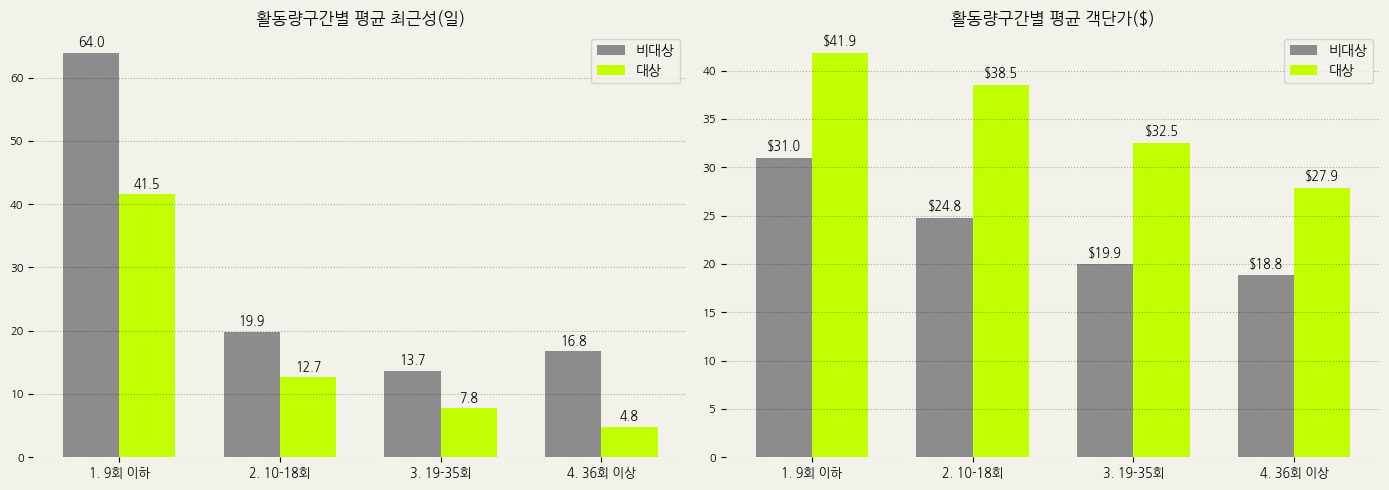

In [23]:
# 목적: 활동량구간별 평균최근성(recency)과 평균객단가(monetary)를 대상/비대상으로 비교 시각화한다
import matplotlib.pyplot as plt
import numpy as np

VOID = "#030303"
SIGNAL = "#C2FF00"
PAPER = "#F2F2EA"
UNTARGETED_COLOR = "#8C8C8C"  # 비대상 그룹은 중립 회색으로 대비

tiers = sorted(recency_monetary["activity_tier"].unique())
x = np.arange(len(tiers))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(PAPER)

# --- 차트1: 평균 최근성(일) ---
ax = axes[0]
ax.set_facecolor(PAPER)
recency_false = [recency_monetary[(recency_monetary["activity_tier"]==t) & (recency_monetary["ever_targeted"]==False)]["avg_recency_days"].values[0] for t in tiers]
recency_true = [recency_monetary[(recency_monetary["activity_tier"]==t) & (recency_monetary["ever_targeted"]==True)]["avg_recency_days"].values[0] for t in tiers]

bars1 = ax.bar(x - width/2, recency_false, width, label="비대상", color=UNTARGETED_COLOR)
bars2 = ax.bar(x + width/2, recency_true, width, label="대상", color=SIGNAL)

for bars in [bars1, bars2]:
    for b in bars:
        height = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, height + 0.5, f"{height:.1f}", ha="center", va="bottom", fontsize=9, color=VOID)

ax.set_title("활동량구간별 평균 최근성(일)", color=VOID, fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(tiers, color=VOID, fontsize=9)
ax.tick_params(axis='y', labelsize=8, colors=VOID)
ax.grid(axis='y', linestyle=':', color=VOID, alpha=0.3)
ax.legend()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- 차트2: 평균 객단가($) ---
ax = axes[1]
ax.set_facecolor(PAPER)
monetary_false = [recency_monetary[(recency_monetary["activity_tier"]==t) & (recency_monetary["ever_targeted"]==False)]["avg_basket_value"].values[0] for t in tiers]
monetary_true = [recency_monetary[(recency_monetary["activity_tier"]==t) & (recency_monetary["ever_targeted"]==True)]["avg_basket_value"].values[0] for t in tiers]

bars1 = ax.bar(x - width/2, monetary_false, width, label="비대상", color=UNTARGETED_COLOR)
bars2 = ax.bar(x + width/2, monetary_true, width, label="대상", color=SIGNAL)

for bars in [bars1, bars2]:
    for b in bars:
        height = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, height + 0.5, f"${height:.1f}", ha="center", va="bottom", fontsize=9, color=VOID)

ax.set_title("활동량구간별 평균 객단가($)", color=VOID, fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(tiers, color=VOID, fontsize=9)
ax.tick_params(axis='y', labelsize=8, colors=VOID)
ax.grid(axis='y', linestyle=':', color=VOID, alpha=0.3)
ax.legend()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**결과 해석**
- 같은 활동량 구간 안에서도 타겟팅된 가구가 비대상 가구보다 최근성이 뚜렷이 낮음(더 최근 구매) — 1구간 기준 대상 41.55일 vs 비대상 63.95일
- 객단가도 전 구간에서 대상 가구가 비대상보다 높음 — 4구간 기준 대상 $27.88 vs 비대상 $18.82
- 즉 활동량 하나만으로는 타겟팅 기준을 설명할 수 없고, 최근성·객단가까지 함께 봐야 함

**다음 단계**
- RFM(최근성·구매횟수·객단가) 점수화해서 대상 가구의 분포를 정량적으로 확인

**RFM 점수화 방식**
- F(구매횟수), M(객단가)는 값이 클수록 좋은 점수 → 오름차순 정렬 후 4분위
- R(최근성)은 값(경과일수)이 작을수록(최근 구매일수록) 좋은 점수 → 내림차순 정렬 후 4분위
- 세 점수를 합산해 RFM 총점(3~12점) 산출

In [25]:
# 목적: RFM 점수화 결과를 확인한다 (f_score, m_score, r_score, rfm_total)
rfm_scored.head(10).rename(columns={
    "household_key": "가구ID",
    "ever_targeted": "타겟팅여부",
    "frequency": "구매횟수",
    "monetary": "객단가($)",
    "recency": "최근성(일)",
    "f_score": "F점수",
    "m_score": "M점수",
    "r_score": "R점수",
    "rfm_total": "RFM총점"
})

,가구ID,타겟팅여부,구매횟수,객단가($),최근성(일),F점수,M점수,R점수,RFM총점
0,2483,True,1,5.000000,223,1,1,1,3
1,528,False,3,13.826667,217,1,1,1,3
2,2352,False,3,119.150000,217,1,4,1,6
3,2397,False,2,14.665000,214,1,1,1,3
4,1432,False,1,57.140000,214,1,4,1,6
5,1629,False,2,34.405000,213,1,3,1,5
6,1110,True,1,3.740000,212,1,1,1,3
7,1827,False,2,11.775000,209,1,1,1,3
8,2414,False,1,3.180000,208,1,1,1,3
9,2165,False,1,2.790000,206,1,1,1,3


In [24]:
# 목적: 타겟팅된 가구들의 RFM 총점 평균/중앙값을 확인한다
targeted_rfm_benchmark = duckdb.sql("""
    SELECT
        ROUND(AVG(rfm_total), 2) AS avg_rfm_total,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY rfm_total) AS median_rfm_total
    FROM rfm_scored
    WHERE ever_targeted = TRUE
""").df()

targeted_rfm_benchmark.rename(columns={
    "avg_rfm_total": "평균RFM총점",
    "median_rfm_total": "중앙값RFM총점"
})

,평균RFM총점,중앙값RFM총점
0,8.56,9.0


### 결과 해석
- 대상 가구 평균 RFM 점수 8.56, 중앙값 9.0 — 서로 근접하지만, 이 회사가 실제로 어떤 기준으로 캠페인 타겟팅을 하는지 더 깊이 파악하기 위해 대상 가구 내부의 하위권 분포도 확인한다

In [26]:
# 목적: 타겟팅된 가구들의 RFM 총점 하위 분포(하위 25% 등)를 확인한다
rfm_distribution = duckdb.sql("""
    SELECT
        MIN(rfm_total) AS min_rfm,
        PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY rfm_total) AS p05_rfm,
        PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY rfm_total) AS p10_rfm,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY rfm_total) AS p25_rfm
    FROM rfm_scored
    WHERE ever_targeted = TRUE
""").df()

rfm_distribution.rename(columns={
    "min_rfm": "최소RFM총점",
    "p05_rfm": "하위5%",
    "p10_rfm": "하위10%",
    "p25_rfm": "하위25%"
})

,최소RFM총점,하위5%,하위10%,하위25%
0,3,5.0,6.0,7.0


In [27]:
# 목적: 대상 가구 중 하위 25%(RFM 7점 이하)의 평균 R/F/M 개별 점수를 확인해 대상 선정 이유를 추정한다
low_rfm_profile = duckdb.sql("""
    SELECT
        COUNT(*) AS household_count,
        ROUND(AVG(f_score), 2) AS avg_f_score,
        ROUND(AVG(m_score), 2) AS avg_m_score,
        ROUND(AVG(r_score), 2) AS avg_r_score,
        ROUND(AVG(rfm_total), 2) AS avg_rfm_total
    FROM rfm_scored
    WHERE ever_targeted = TRUE AND rfm_total <= 7
""").df()

low_rfm_profile.rename(columns={
    "household_count": "가구수",
    "avg_f_score": "평균F점수",
    "avg_m_score": "평균M점수",
    "avg_r_score": "평균R점수",
    "avg_rfm_total": "평균RFM총점"
})

,가구수,평균F점수,평균M점수,평균R점수,평균RFM총점
0,430,2.2,2.09,1.85,6.15


**결과 해석**
- 대상 가구 하위 25%(RFM 7점 이하)의 평균 점수: F=2.2, M=2.09, R=1.85
- 세 점수 중 R(최근성)이 상대적으로 가장 낮음 — F, M은 평균 이상인데 R만 유독 낮은 경향
- 즉 이 하위 그룹은 "최근에 구매 안 했어도 구매횟수·객단가가 있으면 타겟팅된" 가구일 가능성 → 순수 우량고객 기준과는 다른 별도 트랙(win-back형) 존재 가능성

**다음 단계**
- 하위 25%를 제외한 나머지(핵심) 그룹의 RFM 기준이 안정적인지 확인
- 별도 win-back 트랙이 실제로 존재하는지 추가 검증

In [28]:
# 목적: 하위 25%(RFM≤7)를 제외한 핵심그룹의 RFM 총점이 안정적인지(중앙값 기준) 확인한다
core_rfm_benchmark = duckdb.sql("""
    SELECT
        COUNT(*) AS household_count,
        ROUND(AVG(rfm_total), 2) AS avg_rfm_total,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY rfm_total) AS median_rfm_total
    FROM rfm_scored
    WHERE ever_targeted = TRUE AND rfm_total > 7
""").df()

core_rfm_benchmark.rename(columns={
    "household_count": "가구수",
    "avg_rfm_total": "평균RFM총점",
    "median_rfm_total": "중앙값RFM총점"
})

,가구수,평균RFM총점,중앙값RFM총점
0,1153,9.46,9.0


In [29]:
# 목적: 비대상 가구 중 핵심그룹 기준(RFM≥9)을 충족하는 "놓친 우량고객" 후보를 추출한다
missed_high_value = duckdb.sql("""
    SELECT *
    FROM rfm_scored
    WHERE ever_targeted = FALSE AND rfm_total >= 9
    ORDER BY rfm_total DESC
""").df()

print("놓친 우량고객 후보 가구 수:", len(missed_high_value))

missed_high_value.head(10).rename(columns={
    "household_key": "가구ID",
    "ever_targeted": "타겟팅여부",
    "frequency": "구매횟수",
    "monetary": "객단가($)",
    "recency": "최근성(일)",
    "f_score": "F점수",
    "m_score": "M점수",
    "r_score": "R점수",
    "rfm_total": "RFM총점"
})

놓친 우량고객 후보 가구 수: 71


,가구ID,타겟팅여부,구매횟수,객단가($),최근성(일),F점수,M점수,R점수,RFM총점
0,1274,False,75,43.625200,1,4,4,4,12
1,1023,False,110,56.078364,1,4,4,4,12
2,2106,False,37,52.144595,6,4,4,3,11
3,1612,False,44,41.228409,4,4,4,3,11
4,1724,False,35,27.639429,2,4,3,4,11
5,1780,False,22,39.973636,2,3,4,4,11
6,1268,False,28,40.737500,2,3,4,4,11
7,590,False,59,32.455424,1,4,3,4,11
8,2449,False,84,39.219167,1,4,3,4,11
9,1129,False,20,55.628500,5,3,4,3,10


In [30]:
# 목적: 71가구가 최근성에 쏠려있는지(급성장 신규고객 가설), 고객 이력 길이는 어느 정도인지 확인한다
missed_profile = duckdb.sql(f"""
    SELECT
        m.household_key,
        m.recency,
        m.frequency,
        MIN(t.DAY) AS first_purchase_day,
        {CAMPAIGN_START_DAY} - MIN(t.DAY) AS tenure_days
    FROM missed_high_value m
    JOIN transaction_data t ON m.household_key = t.household_key
    WHERE t.DAY < {CAMPAIGN_START_DAY}
    GROUP BY m.household_key, m.recency, m.frequency
    ORDER BY m.recency
""").df()

recency_7_ratio = (missed_profile["recency"] <= 7).mean()
print(f"recency 7일 이하 비중: {recency_7_ratio:.1%}")
print(f"평균 고객이력(캠페인 시작까지 tenure): {missed_profile['tenure_days'].mean():.1f}일")

missed_profile.describe()

recency 7일 이하 비중: 97.2%
평균 고객이력(캠페인 시작까지 tenure): 154.1일


,household_key,recency,frequency,first_purchase_day,tenure_days
count,71.000000,71.000000,71.000000,71.000000,71.000000
mean,1232.591549,2.830986,28.070423,69.887324,154.112676
std,620.213732,2.431848,30.295367,27.961989,27.961989
min,24.000000,1.000000,6.000000,12.000000,110.000000
25%,804.500000,1.000000,12.000000,49.000000,129.500000
50%,1129.000000,2.000000,17.000000,71.000000,153.000000
75%,1727.000000,4.000000,33.000000,94.500000,175.000000
max,2449.000000,16.000000,200.000000,114.000000,212.000000


**결과 해석**
- 71가구의 recency 집중(97.2%가 7일 이하)은 신규 고객이라서가 아니라, 원래 자주 구매하는 고객이면 어느 시점에서 잘라도 최근 구매일이 가까울 수밖에 없다는 통계적 특성임
- tenure(첫 구매~캠페인 시작까지) 평균 154일, 최소 110일 — 캠페인 훨씬 전부터 활동해온 고객들로, "데이터가 부족해서 못 봤다"는 설명은 성립하기 어려움
- 즉 이 71가구는 정당하게 "놓친 기회"로 볼 수 있는 근거가 보강됨

**다음 단계**
- 하위 25%에서 발견된 R점수 낮은 패턴이 실제 별도의 win-back 트랙인지 추가 검증

In [31]:
# 목적: 핵심그룹(RFM>7)과 win-back추정그룹(RFM≤7)이 캠페인 타입 구성에서 차이가 있는지 확인한다
campaign_type_by_segment = duckdb.sql("""
    SELECT
        CASE WHEN r.rfm_total > 7 THEN '핵심그룹' ELSE 'win-back추정그룹' END AS segment,
        d.DESCRIPTION AS campaign_type,
        COUNT(DISTINCT r.household_key) AS household_count
    FROM rfm_scored r
    JOIN campaign_table c ON r.household_key = c.household_key
    JOIN campaign_desc d ON c.CAMPAIGN = d.CAMPAIGN
    WHERE r.ever_targeted = TRUE
    GROUP BY segment, d.DESCRIPTION
    ORDER BY segment, d.DESCRIPTION
""").df()

campaign_type_by_segment.rename(columns={
    "segment": "그룹",
    "campaign_type": "캠페인타입",
    "household_count": "가구수"
})

,그룹,캠페인타입,가구수
0,win-back추정그룹,TypeA,385
1,win-back추정그룹,TypeB,202
2,win-back추정그룹,TypeC,59
3,핵심그룹,TypeA,1127
4,핵심그룹,TypeB,820
5,핵심그룹,TypeC,338


In [32]:
# 목적: 저최근성(R점수≤2) 그룹 안에서 대상/비대상 가구의 F/M 값을 비교한다
low_recency_comparison = duckdb.sql("""
    SELECT
        ever_targeted,
        COUNT(*) AS household_count,
        ROUND(AVG(f_score), 2) AS avg_f_score,
        ROUND(AVG(m_score), 2) AS avg_m_score,
        ROUND(AVG(frequency), 2) AS avg_frequency,
        ROUND(AVG(monetary), 2) AS avg_monetary
    FROM rfm_scored
    WHERE r_score <= 2
    GROUP BY ever_targeted
""").df()

low_recency_comparison.rename(columns={
    "ever_targeted": "타겟팅여부",
    "household_count": "가구수",
    "avg_f_score": "평균F점수",
    "avg_m_score": "평균M점수",
    "avg_frequency": "평균구매횟수",
    "avg_monetary": "평균객단가($)"
})

,타겟팅여부,가구수,평균F점수,평균M점수,평균구매횟수,평균객단가($)
0,False,706,1.46,2.24,8.46,28.46
1,True,542,2.50,2.65,23.03,33.68


**결과 해석**
- R점수가 낮은(비최근) 가구들 안에서도 대상 가구는 F=2.50/M=2.65로 비대상(F=1.46/M=2.24)보다 뚜렷이 높음
- 구매횟수도 대상 23.03회 vs 비대상 8.46회, 객단가도 $33.68 vs $28.46 — 캠페인타입보다 훨씬 명확한 차이
- 즉 "최근성은 낮아도 구매횟수·객단가가 받쳐주는 가구"가 별도로 타겟팅됐다는 win-back 트랙 가설이 이 비교로 뒷받침됨

**다음 단계**
- 대상 가구의 F/M 중앙값을 win-back 기준선으로 삼아, 비대상 중 이 기준을 충족하는 후보 추출

## 종합: 회사의 타겟팅 기준(추정)

지금까지 확인한 내용을 종합하면, 이 회사는 하나의 기준이 아니라 두 가지 트랙으로 캠페인 대상을 선정한 것으로 추정된다.

- **핵심 우량고객 트랙**: RFM 총점 ≥ 9 (핵심그룹 중앙값 기준) — 구매횟수·최근성·객단가가 고르게 높은 가구
- **win-back 트랙**: 최근성은 낮지만(비활성 상태) 구매횟수·객단가가 일정 수준 이상인 가구 — 이탈 위험이 있는 과거 우량고객을 다시 끌어들이려는 목적으로 추정

핵심 트랙의 기준(RFM≥9)은 앞서 확인했으니, 이어서 win-back 트랙의 정확한 F·M 기준선을 데이터로 확인한다.

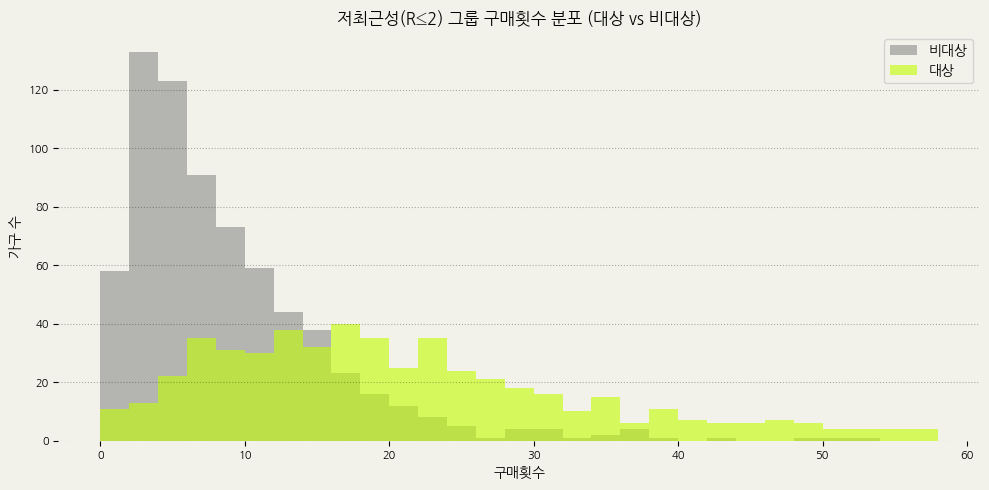

In [33]:
# 목적: 저최근성(R≤2) 그룹의 구매횟수 분포를 대상/비대상으로 겹쳐서 확인한다 (자연스러운 경계선이 있는지)
import matplotlib.pyplot as plt

VOID = "#030303"
SIGNAL = "#C2FF00"
PAPER = "#F2F2EA"
UNTARGETED_COLOR = "#8C8C8C"

low_r = rfm_scored[rfm_scored["r_score"] <= 2]
targeted_freq = low_r[low_r["ever_targeted"] == True]["frequency"]
untargeted_freq = low_r[low_r["ever_targeted"] == False]["frequency"]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(PAPER)
ax.set_facecolor(PAPER)

bins = range(0, 60, 2)
ax.hist(untargeted_freq, bins=bins, alpha=0.6, label="비대상", color=UNTARGETED_COLOR)
ax.hist(targeted_freq, bins=bins, alpha=0.6, label="대상", color=SIGNAL)

ax.set_title("저최근성(R≤2) 그룹 구매횟수 분포 (대상 vs 비대상)", color=VOID, fontsize=12)
ax.set_xlabel("구매횟수", color=VOID)
ax.set_ylabel("가구 수", color=VOID)
ax.tick_params(colors=VOID, labelsize=8)
ax.grid(axis='y', linestyle=':', color=VOID, alpha=0.3)
ax.legend()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**결과 해석**
- 비대상 그룹(회색)은 구매횟수 0~15 구간에 집중적으로 몰려있음
- 대상 그룹(연두)은 상대적으로 더 넓게 분포하며 20회 이상에서도 꾸준히 나타남
- 두 그룹 사이에 명확한 자연 경계선은 없고 5~30회 구간에서 상당히 겹침 — 즉 "몇 회 이상이면 win-back 대상"이라고 눈으로 잘라낼 수 있는 지점은 없음

**다음 단계**
- 자연스러운 경계선이 없으므로, 실제 타겟팅된 가구들의 F·M 중앙값을 기준선으로 사용

In [34]:
# 목적: 저최근성(R≤2) 그룹에서 실제 타겟팅된 가구들의 구매횟수·객단가 중앙값을 확인해 win-back 기준선으로 사용한다
winback_benchmark = duckdb.sql("""
    SELECT
        ROUND(AVG(frequency), 2) AS avg_frequency,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY frequency) AS median_frequency,
        ROUND(AVG(monetary), 2) AS avg_monetary,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY monetary) AS median_monetary
    FROM rfm_scored
    WHERE ever_targeted = TRUE AND r_score <= 2
""").df()

winback_benchmark.rename(columns={
    "avg_frequency": "평균구매횟수",
    "median_frequency": "중앙값구매횟수",
    "avg_monetary": "평균객단가($)",
    "median_monetary": "중앙값객단가($)"
})

,평균구매횟수,중앙값구매횟수,평균객단가($),중앙값객단가($)
0,23.03,19.0,33.68,27.658611


In [35]:
# 목적: 비대상 가구 중 win-back 기준선(중앙값)을 충족하는 후보를 추출한다
winback_candidates = duckdb.sql("""
    SELECT *
    FROM rfm_scored
    WHERE ever_targeted = FALSE
      AND r_score <= 2
      AND frequency >= 19
      AND monetary >= 27.66
      AND rfm_total < 9
    ORDER BY frequency DESC
""").df()

print("win-back 후보 가구 수:", len(winback_candidates))

winback_candidates.rename(columns={
    "household_key": "가구ID",
    "ever_targeted": "타겟팅여부",
    "frequency": "구매횟수",
    "monetary": "객단가($)",
    "recency": "최근성(일)",
    "f_score": "F점수",
    "m_score": "M점수",
    "r_score": "R점수",
    "rfm_total": "RFM총점"
})

win-back 후보 가구 수: 7


,가구ID,타겟팅여부,구매횟수,객단가($),최근성(일),F점수,M점수,R점수,RFM총점
0,1080,False,34,28.382647,28,3,3,1,7
1,1410,False,30,38.786000,33,3,3,1,7
2,107,False,29,31.228276,16,3,3,2,8
3,547,False,24,29.370833,19,3,3,2,8
4,1358,False,23,35.359130,83,3,3,1,7
5,1112,False,20,35.537000,15,3,3,2,8
6,799,False,20,28.959000,7,3,3,2,8


In [38]:
# 목적: win-back 후보 7가구의 고객 이력(tenure)을 확인해 정당한 win-back 대상인지 검토한다
winback_profile = duckdb.sql(f"""
    SELECT
        w.household_key,
        w.recency,
        w.frequency,
        MIN(t.DAY) AS first_purchase_day,
        {CAMPAIGN_START_DAY} - MIN(t.DAY) AS tenure_days
    FROM winback_candidates w
    JOIN transaction_data t ON w.household_key = t.household_key
    WHERE t.DAY < {CAMPAIGN_START_DAY}
    GROUP BY w.household_key, w.recency, w.frequency
    ORDER BY w.recency DESC
""").df()

print("평균 tenure(첫 구매~캠페인 시작까지):", round(winback_profile["tenure_days"].mean(), 1), "일")
print("평균 recency(마지막 구매~캠페인 시작까지):", round(winback_profile["recency"].mean(), 1), "일")

winback_profile.rename(columns={
    "household_key": "가구ID",
    "recency": "최근성(일)",
    "frequency": "구매횟수",
    "first_purchase_day": "첫구매일",
    "tenure_days": "고객이력(일)"
})

평균 tenure(첫 구매~캠페인 시작까지): 163.7 일
평균 recency(마지막 구매~캠페인 시작까지): 28.7 일


,가구ID,최근성(일),구매횟수,첫구매일,고객이력(일)
0,1358,83,23,80,144
1,1410,33,30,37,187
2,1080,28,34,20,204
3,547,19,24,93,131
4,107,16,29,66,158
5,1112,15,20,96,128
6,799,7,20,30,194


**결과 해석**
- win-back 후보 7가구는 평균 고객이력 163.7일로, 캠페인 훨씬 이전부터 활동해온 오래된 고객임
- 평균 최근성은 28.7일(범위 7~83일)로, 최근엔 구매가 뜸해진 상태
- 즉 "오래 거래해온 고객인데 최근 들어 발길이 뜸해진" 전형적인 win-back 대상 패턴과 일치함 — 데이터 이상치가 아니라 정당한 후보군으로 판단

## H2 결론

- 활동량만으로는 타겟팅 기준을 설명할 수 없고, 최근성·객단가까지 함께 봐야 함을 확인함
- 타겟팅된 가구는 두 가지 트랙으로 나뉘는 것으로 추정됨:
  1. 핵심 우량고객 트랙 — RFM 총점 ≥ 9 (핵심그룹 중앙값 기준)
  2. win-back 트랙 — 최근성은 낮지만 구매횟수(≥19회)·객단가(≥$27.66)가 중앙값 이상인 가구
- 두 기준을 비대상 가구에 적용해 핵심그룹 71가구, win-back 후보 7가구를 확인함 (모두 신규 유입이 아닌, 일정 기간 이상 실제 구매 이력이 쌓인 가구로 검증됨)

## H3. 그렇다면 회사가 놓친 가구는 얼마나 되나?

- H2에서 정의한 두 기준(핵심그룹 RFM≥9, win-back 구매횟수≥19·객단가≥$27.66)을 비대상 가구에 적용한 결과, 핵심 우량고객 71가구·win-back 후보 7가구, **총 78가구**를 놓친 것으로 파악됨

## H4. 가구 특성별로 얼마나 매출을 더 챙길 수 있나?

- H3에서 파악한 78가구(핵심 71 + win-back 7)를 실제로 타겟팅했다면 얼마나 더 매출을 얻을 수 있었을지 계산한다
- 계산 전에, 대상/비대상 그룹 간 uplift 차이가 통계적으로 유의한지 먼저 검증한다 (우연에 의한 차이가 아님을 확인)

In [36]:
# 목적: 핵심그룹(RFM>7 타겟팅 vs RFM≥9 비타겟팅 71가구)의 daily_uplift 차이가 통계적으로 유의한지 검증한다
from scipy import stats

core_targeted_uplift = duckdb.sql("""
    SELECT s.daily_uplift
    FROM sim_data s
    JOIN rfm_scored r ON s.household_key = r.household_key
    WHERE r.ever_targeted = TRUE AND r.rfm_total > 7
""").df()["daily_uplift"]

core_missed_uplift = duckdb.sql("""
    SELECT s.daily_uplift
    FROM sim_data s
    JOIN rfm_scored r ON s.household_key = r.household_key
    WHERE r.ever_targeted = FALSE AND r.rfm_total >= 9
""").df()["daily_uplift"]

t_stat, p_value = stats.ttest_ind(core_targeted_uplift, core_missed_uplift, equal_var=False)
print(f"핵심그룹 t-검정: 대상 n={len(core_targeted_uplift)}, 비대상(놓친) n={len(core_missed_uplift)}")
print(f"t={t_stat:.2f}, p={p_value:.10f}")
print(f"대상 평균 daily_uplift: {core_targeted_uplift.mean():.4f}")
print(f"비대상(놓친) 평균 daily_uplift: {core_missed_uplift.mean():.4f}")

핵심그룹 t-검정: 대상 n=1153, 비대상(놓친) n=71
t=3.37, p=0.0011994878
대상 평균 daily_uplift: 2.3260
비대상(놓친) 평균 daily_uplift: 0.0910


In [37]:
# 목적: win-back그룹(저최근성+고F+고M 타겟팅 vs 동일조건 비타겟팅 7가구)의 daily_uplift 차이가 통계적으로 유의한지 검증한다
winback_targeted_uplift = duckdb.sql("""
    SELECT s.daily_uplift
    FROM sim_data s
    JOIN rfm_scored r ON s.household_key = r.household_key
    WHERE r.ever_targeted = TRUE AND r.r_score <= 2
      AND r.frequency >= 19 AND r.monetary >= 27.66
""").df()["daily_uplift"]

winback_missed_uplift = duckdb.sql("""
    SELECT s.daily_uplift
    FROM sim_data s
    JOIN rfm_scored r ON s.household_key = r.household_key
    WHERE r.ever_targeted = FALSE AND r.r_score <= 2
      AND r.frequency >= 19 AND r.monetary >= 27.66 AND r.rfm_total < 9
""").df()["daily_uplift"]

t_stat, p_value = stats.ttest_ind(winback_targeted_uplift, winback_missed_uplift, equal_var=False)
print(f"win-back그룹 t-검정: 대상 n={len(winback_targeted_uplift)}, 비대상(놓친) n={len(winback_missed_uplift)}")
print(f"t={t_stat:.2f}, p={p_value:.10f}")
print(f"대상 평균 daily_uplift: {winback_targeted_uplift.mean():.4f}")
print(f"비대상(놓친) 평균 daily_uplift: {winback_missed_uplift.mean():.4f}")

win-back그룹 t-검정: 대상 n=107, 비대상(놓친) n=7
t=3.97, p=0.0012366416
대상 평균 daily_uplift: 1.1881
비대상(놓친) 평균 daily_uplift: -1.3168


**결과 해석**
- 핵심그룹: t=3.37, p=0.0012 — 유의미한 차이 확인
- win-back그룹: t=3.97, p=0.0012 — 표본이 7개로 작지만 유의미한 차이 확인
- 두 그룹 모두 우연이 아닌 실제 캠페인 효과로 판단 가능 → 매출임팩트 계산 진행

In [40]:
# 목적: 핵심그룹(71가구) 놓친 매출임팩트를 계산한다
core_uplift_gap = core_targeted_uplift.mean() - core_missed_uplift.mean()
core_missed_revenue = 71 * core_uplift_gap * POST_DAYS

core_revenue_impact = pd.DataFrame({
    "놓친가구수": [71],
    "일평균매출격차($)": [round(core_uplift_gap, 4)],
    "놓친매출($)": [round(core_missed_revenue, 2)]
})
core_revenue_impact

,놓친가구수,일평균매출격차($),놓친매출($)
0,71,2.2349,77435.23


In [41]:
# 목적: win-back그룹(7가구) 놓친 매출임팩트를 계산한다
winback_uplift_gap = winback_targeted_uplift.mean() - winback_missed_uplift.mean()
winback_missed_revenue = 7 * winback_uplift_gap * POST_DAYS

winback_revenue_impact = pd.DataFrame({
    "놓친가구수": [7],
    "일평균매출격차($)": [round(winback_uplift_gap, 4)],
    "놓친매출($)": [round(winback_missed_revenue, 2)]
})
winback_revenue_impact

,놓친가구수,일평균매출격차($),놓친매출($)
0,7,2.5049,8556.77


In [42]:
# 목적: 핵심그룹+win-back그룹 총 놓친 매출임팩트를 합산한다
total_missed_revenue = core_missed_revenue + winback_missed_revenue

total_revenue_impact = pd.DataFrame({
    "구분": ["핵심그룹(71가구)", "win-back그룹(7가구)", "합계(78가구)"],
    "놓친매출($)": [round(core_missed_revenue, 2), round(winback_missed_revenue, 2), round(total_missed_revenue, 2)]
})
total_revenue_impact

,구분,놓친매출($)
0,핵심그룹(71가구),77435.23
1,win-back그룹(7가구),8556.77
2,합계(78가구),85992.00


## H4 결론

- 핵심그룹(71가구): t=3.37, p=0.0012로 유의미한 uplift 격차 확인, 놓친 매출 77,435.23달러
- win-back그룹(7가구): t=3.97, p=0.0012로 표본이 작음에도 유의미한 격차 확인, 놓친 매출 8,556.77달러
- 총 78가구를 타겟팅했다면 488일간 약 85,992.00달러의 추가 매출을 얻을 수 있었을 것으로 추정됨

In [44]:
# 목적: RFM 총점별 대상/비대상 가구수를 비교하고, 비대상 가구가 대상 가구 대비 얼마나 앞서는지 확인한다
rfm_headcount = duckdb.sql("""
    SELECT rfm_total,
        SUM(CASE WHEN ever_targeted = FALSE THEN 1 ELSE 0 END) AS untargeted_count,
        SUM(CASE WHEN ever_targeted = TRUE THEN 1 ELSE 0 END) AS targeted_count
    FROM rfm_scored
    GROUP BY rfm_total
    ORDER BY rfm_total
""").df()

# 각 RFM 점수보다 낮은 점수를 받은 "대상" 가구가 몇 명인지 누적 계산
rfm_headcount["targeted_below"] = rfm_headcount["targeted_count"].cumsum().shift(1).fillna(0).astype(int)
total_targeted = rfm_headcount["targeted_count"].sum()
rfm_headcount["targeted_below_pct"] = round(rfm_headcount["targeted_below"] / total_targeted * 100, 1)

rfm_headcount.rename(columns={
    "rfm_total": "RFM총점",
    "untargeted_count": "비대상가구수",
    "targeted_count": "대상가구수",
    "targeted_below": "이보다낮은대상가구수",
    "targeted_below_pct": "이보다낮은대상가구비율(%)"
})

,RFM총점,비대상가구수,대상가구수,이보다낮은대상가구수,이보다낮은대상가구비율(%)
0,3,125.0,13.0,0,0.0
1,4,139.0,25.0,13,0.8
2,5,172.0,54.0,38,2.4
3,6,220.0,132.0,92,5.8
4,7,105.0,206.0,224,14.2
5,8,81.0,299.0,430,27.2
6,9,45.0,326.0,729,46.1
7,10,17.0,291.0,1055,66.6
8,11,7.0,173.0,1346,85.0
9,12,2.0,64.0,1519,96.0


In [45]:
# 목적: RFM=8 비대상 가구군과 이미 H4에서 계산한 win-back 7가구가 겹치는지 확인한다
rfm8_untargeted = set(rfm_scored[(rfm_scored["ever_targeted"]==False) & (rfm_scored["rfm_total"]==8)]["household_key"])
winback_set = set(winback_candidates["household_key"])

overlap = rfm8_untargeted & winback_set
print("RFM=8 비대상 가구 수:", len(rfm8_untargeted))
print("win-back 7가구 중 RFM=8과 겹치는 가구 수:", len(overlap))
print("winback_candidates의 RFM총점 분포:")
print(winback_candidates["rfm_total"].value_counts())

RFM=8 비대상 가구 수: 81
win-back 7가구 중 RFM=8과 겹치는 가구 수: 4
winback_candidates의 RFM총점 분포:
rfm_total
8    4
7    3
Name: count, dtype: int64


In [46]:
# 목적: RFM=8 근접미달군(win-back 7가구 제외한 77가구)의 F/M/R 개별 점수 조합을 확인한다
near_core_candidates = duckdb.sql("""
    SELECT * FROM rfm_scored
    WHERE ever_targeted = FALSE AND rfm_total = 8
""").df()

winback_keys = set(winback_candidates["household_key"])
near_core_candidates = near_core_candidates[~near_core_candidates["household_key"].isin(winback_keys)]

print("근접미달군 가구 수:", len(near_core_candidates))
print("\nF/M/R 점수 조합별 가구 수:")
print(near_core_candidates.groupby(["f_score", "m_score", "r_score"]).size().sort_values(ascending=False))

근접미달군 가구 수: 77

F/M/R 점수 조합별 가구 수:
f_score  m_score  r_score
2        4        2          17
         2        4          14
4        1        3           9
3        1        4           9
2        3        3           9
1        4        3           6
3        2        3           6
1        3        4           3
3        3        2           2
4        2        2           2
dtype: int64


## 액션 도출

- H4에서 78가구(핵심 71 + win-back 7)를 놓친 매출 기회로 확인했지만, 두 그룹은 성격이 달라 같은 액션을 적용하기 어렵다
- 핵심그룹은 이미 활동적·구매력 있는 우량고객이라 "어떤 카테고리로 접근하면 반응이 좋을까"가 관건이고, win-back그룹은 이탈 위험이 있어 "어떤 유인책이 필요한가"가 관건
- 실제 구매 카테고리를 분석해 그룹별 구체적 액션을 도출한다

In [49]:
# 목적: transaction_data에 PRODUCT_ID 컬럼이 있는지, product.csv 파일이 존재하는지 확인한다
print("transaction_data 컬럼:", transaction_data.columns.tolist())

import os
print("\nDATA_DIR 내 파일 목록:", os.listdir(DATA_DIR))

transaction_data 컬럼: ['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY', 'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO', 'COUPON_DISC', 'COUPON_MATCH_DISC']

DATA_DIR 내 파일 목록: ['campaign_desc.csv', 'campaign_table.csv', 'causal_data.csv', 'hh_demographic.csv', 'coupon_redempt.csv', 'transaction_data.csv', 'coupon.csv', 'product.csv']


In [50]:
# 목적: product 테이블(카테고리 정보)을 불러온다
product = pd.read_csv(f"{DATA_DIR}/product.csv")
print(product.columns.tolist())
product.head()

['PRODUCT_ID', 'MANUFACTURER', 'DEPARTMENT', 'BRAND', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'CURR_SIZE_OF_PRODUCT']


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [53]:
# 목적: 핵심그룹(71가구)의 선호 카테고리 분석
core_category = duckdb.sql(f"""
    WITH core_spend AS (
        SELECT p.COMMODITY_DESC, SUM(t.SALES_VALUE) AS core_sales,
            COUNT(DISTINCT t.household_key) AS core_household_count
        FROM transaction_data t
        JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
        WHERE t.household_key IN (SELECT household_key FROM missed_high_value)
          AND t.DAY < {CAMPAIGN_START_DAY}
          AND p.COMMODITY_DESC IS NOT NULL
          AND p.COMMODITY_DESC NOT IN ('', 'NO COMMODITY DESCRIPTION')
        GROUP BY p.COMMODITY_DESC
    ),
    overall_spend AS (
        SELECT p.COMMODITY_DESC, SUM(t.SALES_VALUE) AS overall_sales
        FROM transaction_data t
        JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
        WHERE t.DAY < {CAMPAIGN_START_DAY}
          AND p.COMMODITY_DESC IS NOT NULL
          AND p.COMMODITY_DESC NOT IN ('', 'NO COMMODITY DESCRIPTION')
        GROUP BY p.COMMODITY_DESC
    ),
    core_total AS (SELECT SUM(core_sales) AS total FROM core_spend),
    overall_total AS (SELECT SUM(overall_sales) AS total FROM overall_spend)
    SELECT
        c.COMMODITY_DESC,
        c.core_household_count,
        c.core_sales,
        ROUND(c.core_sales / core_total.total * 100, 3) AS core_share_pct,
        ROUND(o.overall_sales / overall_total.total * 100, 3) AS overall_share_pct,
        ROUND((c.core_sales / core_total.total) / (o.overall_sales / overall_total.total), 2) AS affinity_index
    FROM core_spend c
    JOIN overall_spend o ON c.COMMODITY_DESC = o.COMMODITY_DESC
    CROSS JOIN core_total
    CROSS JOIN overall_total
    WHERE c.core_household_count >= 10 AND c.core_sales > 0
    ORDER BY affinity_index DESC
    LIMIT 15
""").df()

core_category.rename(columns={
    "COMMODITY_DESC": "상품카테고리",
    "core_household_count": "구매가구수",
    "core_sales": "핵심그룹매출($)",
    "core_share_pct": "핵심그룹비중(%)",
    "overall_share_pct": "전체평균비중(%)",
    "affinity_index": "선호도지수"
})

,상품카테고리,구매가구수,핵심그룹매출($),핵심그룹비중(%),전체평균비중(%),선호도지수
0,SYRUPS/TOPPINGS,13,60.68,0.090,0.038,2.38
1,FLORAL-FRESH CUT,12,400.67,0.598,0.263,2.27
2,ELECTRICAL SUPPPLIES,17,167.08,0.249,0.121,2.05
3,BLEACH,21,159.44,0.238,0.116,2.04
4,HOUSEHOLD CLEANG NEEDS,28,661.60,0.987,0.527,1.87
5,ORAL HYGIENE PRODUCTS,29,522.52,0.779,0.453,1.72
6,MISC WINE,12,115.22,0.172,0.104,1.65
7,VALUE ADDED VEGETABLES,14,99.24,0.148,0.092,1.61
8,CIGARETTES,24,1461.29,2.179,1.371,1.59
9,POPCORN,22,167.38,0.250,0.158,1.58


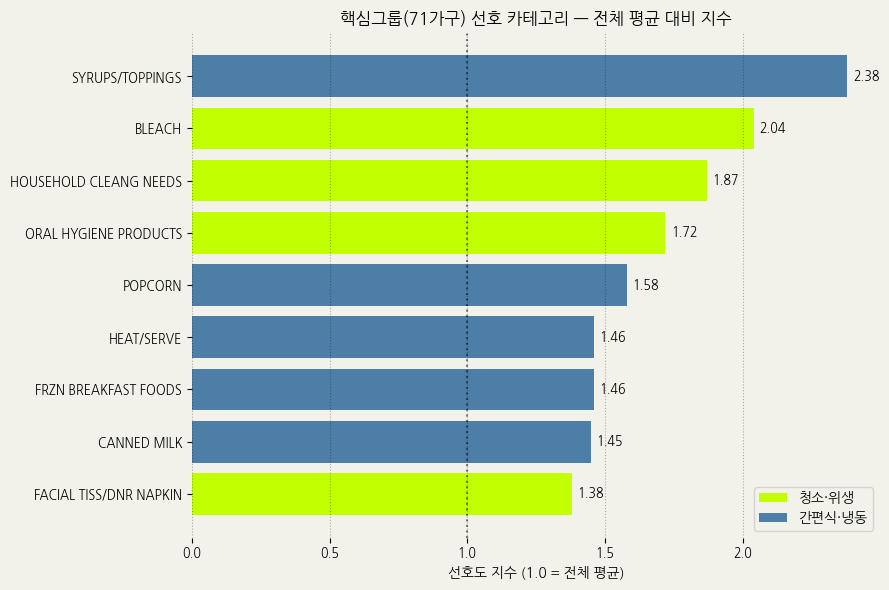

In [56]:
# 목적: 핵심그룹(71가구)의 두 핵심 카테고리 축(청소·위생용품 / 간편식·냉동식품)을 막대그래프로 시각화한다
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

VOID = "#030303"
SIGNAL = "#C2FF00"
PAPER = "#F2F2EA"
SECOND_COLOR = "#4D7EA8"

cleaning_hygiene = ["BLEACH", "HOUSEHOLD CLEANG NEEDS", "ELECTRICAL SUPPLIES", "ORAL HYGIENE PRODUCTS", "FACIAL TISS/DNR NAPKIN"]
convenience_frozen = ["SYRUPS/TOPPINGS", "POPCORN", "HEAT/SERVE", "FRZN BREAKFAST FOODS", "CANNED MILK"]

chart_data = core_category[core_category["COMMODITY_DESC"].isin(cleaning_hygiene + convenience_frozen)].copy()
chart_data["테마"] = chart_data["COMMODITY_DESC"].apply(lambda x: "청소·위생" if x in cleaning_hygiene else "간편식·냉동")
chart_data = chart_data.sort_values("affinity_index", ascending=True)

colors = [SIGNAL if t == "청소·위생" else SECOND_COLOR for t in chart_data["테마"]]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(PAPER)
ax.set_facecolor(PAPER)

bars = ax.barh(chart_data["COMMODITY_DESC"], chart_data["affinity_index"], color=colors)

for b in bars:
    width = b.get_width()
    ax.text(width + 0.02, b.get_y() + b.get_height()/2, f"{width:.2f}", va="center", fontsize=9, color=VOID)

ax.axvline(x=1, color=VOID, linestyle=":", alpha=0.5)
ax.set_title("핵심그룹(71가구) 선호 카테고리 — 전체 평균 대비 지수", color=VOID, fontsize=12)
ax.set_xlabel("선호도 지수 (1.0 = 전체 평균)", color=VOID)
ax.tick_params(colors=VOID, labelsize=9)
ax.grid(axis='x', linestyle=':', color=VOID, alpha=0.3)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements = [Patch(facecolor=SIGNAL, label='청소·위생'), Patch(facecolor=SECOND_COLOR, label='간편식·냉동')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

**왜 이 분석을 하는가**
- 지금까지는 "할인쿠폰을 제안한다"까지만 나왔는데, 할인 규모가 빠져 있어 추상적임
- 실제로 이 카테고리들에 캠페인 기간 동안 쿠폰/할인이 얼마나 적용됐는지 확인해서, 데이터 근거가 있는 구체적인 할인 규모를 제안하려 함

In [60]:
# 목적: 핵심그룹 카테고리(청소·위생+간편식)에서 실제 타겟팅된 가구의 쿠폰 적용 비율/평균 할인액을 확인한다
core_categories = cleaning_hygiene + convenience_frozen

core_discount = duckdb.sql(f"""
    SELECT
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN t.COUPON_DISC != 0 THEN 1 ELSE 0 END) AS coupon_used_transactions,
        ROUND(SUM(CASE WHEN t.COUPON_DISC != 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS coupon_usage_rate_pct,
        ROUND(AVG(CASE WHEN t.COUPON_DISC != 0 THEN ABS(t.COUPON_DISC) END), 3) AS avg_coupon_disc_when_used,
        ROUND(AVG(t.SALES_VALUE), 3) AS avg_sales_value
    FROM transaction_data t
    JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
    WHERE t.household_key IN (SELECT household_key FROM rfm_scored WHERE ever_targeted = TRUE)
      AND t.DAY >= {CAMPAIGN_START_DAY}
      AND p.COMMODITY_DESC IN ({','.join([f"'{c}'" for c in core_categories])})
""").df()

core_discount.rename(columns={
    "total_transactions": "전체거래건수",
    "coupon_used_transactions": "쿠폰사용건수",
    "coupon_usage_rate_pct": "쿠폰사용률(%)",
    "avg_coupon_disc_when_used": "사용시평균할인액($)",
    "avg_sales_value": "평균거래금액($)"
})

,전체거래건수,쿠폰사용건수,쿠폰사용률(%),사용시평균할인액($),평균거래금액($)
0,38710,1507.0,3.89,0.949,3.066


**결과 해석**
- 핵심그룹 카테고리(청소·위생+간편식) 거래 38,710건 중 쿠폰 사용 1,507건(3.89%) — 사용률 자체는 낮은 편
- 쿠폰 사용 시 평균 할인액 $0.949, 평균 거래금액 $3.066 대비 약 31% 수준의 할인폭

In [63]:
# 목적: 핵심그룹(71가구)의 장바구니(BASKET_ID)당 핵심 카테고리 지출 분포를 확인해 임계치 할인 기준을 잡는다
core_basket = duckdb.sql(f"""
    SELECT
        t.household_key, t.BASKET_ID,
        SUM(t.SALES_VALUE) AS basket_category_spend
    FROM transaction_data t
    JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
    WHERE t.household_key IN (SELECT household_key FROM missed_high_value)
      AND t.DAY < {CAMPAIGN_START_DAY}
      AND p.COMMODITY_DESC IN ({','.join([f"'{c}'" for c in core_categories])})
    GROUP BY t.household_key, t.BASKET_ID
""").df()

core_basket_summary = pd.DataFrame({
    "장바구니수": [len(core_basket)],
    "평균카테고리지출($)": [round(core_basket["basket_category_spend"].mean(), 2)],
    "중앙값($)": [round(core_basket["basket_category_spend"].median(), 2)],
    "75th퍼센타일($)": [round(core_basket["basket_category_spend"].quantile(0.75), 2)]
})
core_basket_summary

,장바구니수,평균카테고리지출($),중앙값($),75th퍼센타일($)
0,364,6.65,3.99,5.99


**결과 해석**
- 핵심그룹(71가구)은 두 가지 카테고리 축에서 전체 평균 대비 뚜렷하게 높은 구매 비중을 보임
  - 청소·위생용품: BLEACH(지수 2.04), HOUSEHOLD CLEANG NEEDS(1.87), ELECTRICAL SUPPLIES(2.05), ORAL HYGIENE PRODUCTS(1.72), FACIAL TISS/DNR NAPKIN(1.38)
  - 간편식/냉동식품: HEAT/SERVE(1.46), FRZN BREAKFAST FOODS(1.46), CANNED MILK(1.45), POPCORN(1.58), SYRUPS/TOPPINGS(2.38)
- 신선식품보다는 생활 소모품과 조리 편의성 중심의 소비 패턴으로 판단됨 (담배·주류는 캠페인 소재로 부적절해 제외)

**핵심그룹(71가구) 액션 제안**
- 청소·위생용품·간편식/냉동식품 카테고리에서 6달러 이상 구매 시(장바구니당 지출 75th 퍼센타일 5.99달러 기준) 약 2달러 할인 쿠폰(과거 평균 할인율 31% 기준)을 계산대 즉석 출력 쿠폰 또는 우편 쿠폰북(DM)으로 제공할 것을 제안한다. 이미 활동적·구매력 있는 고객군이므로 기존 캠페인 로직에 포함시키는 것만으로 충분한 반응이 기대된다.

In [55]:
# 목적: win-back 프로필 타겟팅된 107가구의 선호 카테고리 분석 — 카테고리명 결측/공백 행 제외
winback_category = duckdb.sql(f"""
    WITH winback_spend AS (
        SELECT p.COMMODITY_DESC, SUM(t.SALES_VALUE) AS winback_sales,
            COUNT(DISTINCT t.household_key) AS winback_household_count
        FROM transaction_data t
        JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
        JOIN rfm_scored r ON t.household_key = r.household_key
        WHERE r.ever_targeted = TRUE AND r.r_score <= 2
          AND r.frequency >= 19 AND r.monetary >= 27.66
          AND t.DAY < {CAMPAIGN_START_DAY}
          AND p.COMMODITY_DESC IS NOT NULL
          AND TRIM(p.COMMODITY_DESC) != ''
          AND UPPER(TRIM(p.COMMODITY_DESC)) != 'NO COMMODITY DESCRIPTION'
        GROUP BY p.COMMODITY_DESC
    ),
    overall_spend AS (
        SELECT p.COMMODITY_DESC, SUM(t.SALES_VALUE) AS overall_sales
        FROM transaction_data t
        JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
        WHERE t.DAY < {CAMPAIGN_START_DAY}
          AND p.COMMODITY_DESC IS NOT NULL
          AND TRIM(p.COMMODITY_DESC) != ''
          AND UPPER(TRIM(p.COMMODITY_DESC)) != 'NO COMMODITY DESCRIPTION'
        GROUP BY p.COMMODITY_DESC
    ),
    winback_total AS (SELECT SUM(winback_sales) AS total FROM winback_spend),
    overall_total AS (SELECT SUM(overall_sales) AS total FROM overall_spend)
    SELECT
        w.COMMODITY_DESC,
        w.winback_household_count,
        w.winback_sales,
        ROUND(w.winback_sales / winback_total.total * 100, 3) AS winback_share_pct,
        ROUND(o.overall_sales / overall_total.total * 100, 3) AS overall_share_pct,
        ROUND((w.winback_sales / winback_total.total) / (o.overall_sales / overall_total.total), 2) AS affinity_index
    FROM winback_spend w
    JOIN overall_spend o ON w.COMMODITY_DESC = o.COMMODITY_DESC
    CROSS JOIN winback_total
    CROSS JOIN overall_total
    WHERE w.winback_household_count >= 15 AND w.winback_sales > 0
    ORDER BY affinity_index DESC
    LIMIT 15
""").df()

winback_category.rename(columns={
    "COMMODITY_DESC": "상품카테고리",
    "winback_household_count": "구매가구수",
    "winback_sales": "win-back그룹매출($)",
    "winback_share_pct": "win-back그룹비중(%)",
    "overall_share_pct": "전체평균비중(%)",
    "affinity_index": "선호도지수"
})

,상품카테고리,구매가구수,win-back그룹매출($),win-back그룹비중(%),전체평균비중(%),선호도지수
0,LAUNDRY ADDITIVES,54,564.91,0.385,0.259,1.48
1,CIGARETTES,35,2989.90,2.035,1.371,1.48
2,CONVENIENT BRKFST/WHLSM SNACKS,79,1529.25,1.041,0.713,1.46
3,CITRUS,65,405.61,0.276,0.195,1.42
4,INSECTICIDES,18,133.69,0.091,0.065,1.39
5,DIAPERS & DISPOSABLES,26,1523.10,1.037,0.759,1.37
6,WATER - CARBONATED/FLVRD DRINK,80,1803.39,1.228,0.911,1.35
7,SYRUPS/TOPPINGS,21,74.65,0.051,0.038,1.34
8,MELONS,53,502.05,0.342,0.257,1.33
9,PEPPERS-ALL,55,364.67,0.248,0.190,1.31


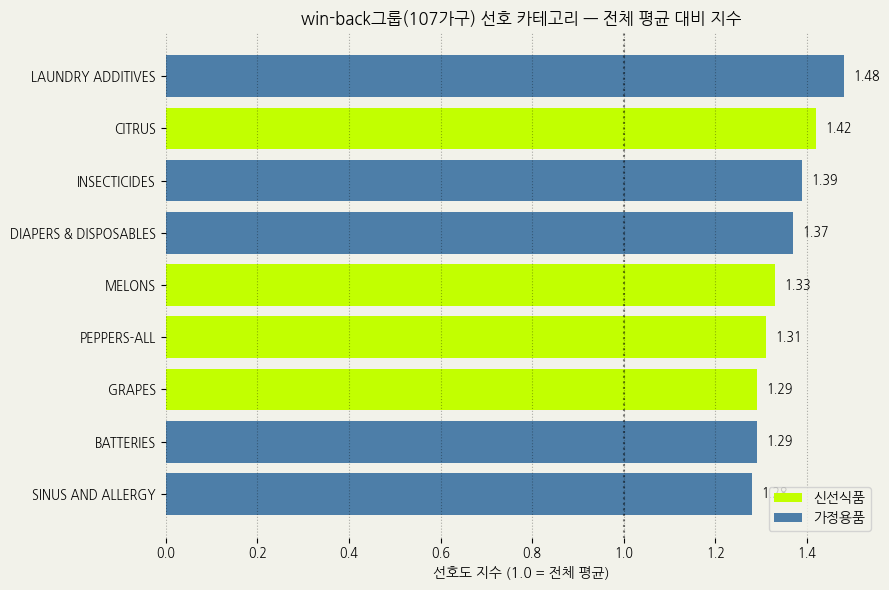

In [57]:
# 목적: win-back그룹(107가구)의 두 핵심 카테고리 축(신선식품 / 가정용품)을 막대그래프로 시각화한다
fresh_produce = ["CITRUS", "MELONS", "PEPPERS-ALL", "GRAPES"]
household_family = ["LAUNDRY ADDITIVES", "INSECTICIDES", "DIAPERS & DISPOSABLES", "BATTERIES", "SINUS AND ALLERGY"]

chart_data2 = winback_category[winback_category["COMMODITY_DESC"].isin(fresh_produce + household_family)].copy()
chart_data2["테마"] = chart_data2["COMMODITY_DESC"].apply(lambda x: "신선식품" if x in fresh_produce else "가정용품")
chart_data2 = chart_data2.sort_values("affinity_index", ascending=True)

colors2 = [SIGNAL if t == "신선식품" else SECOND_COLOR for t in chart_data2["테마"]]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(PAPER)
ax.set_facecolor(PAPER)

bars = ax.barh(chart_data2["COMMODITY_DESC"], chart_data2["affinity_index"], color=colors2)

for b in bars:
    width = b.get_width()
    ax.text(width + 0.02, b.get_y() + b.get_height()/2, f"{width:.2f}", va="center", fontsize=9, color=VOID)

ax.axvline(x=1, color=VOID, linestyle=":", alpha=0.5)
ax.set_title("win-back그룹(107가구) 선호 카테고리 — 전체 평균 대비 지수", color=VOID, fontsize=12)
ax.set_xlabel("선호도 지수 (1.0 = 전체 평균)", color=VOID)
ax.tick_params(colors=VOID, labelsize=9)
ax.grid(axis='x', linestyle=':', color=VOID, alpha=0.3)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements2 = [Patch(facecolor=SIGNAL, label='신선식품'), Patch(facecolor=SECOND_COLOR, label='가정용품')]
ax.legend(handles=legend_elements2, loc='lower right')

plt.tight_layout()
plt.show()

In [61]:
# 목적: win-back그룹 카테고리(신선식품+가정용품)에서 실제 타겟팅된 가구의 쿠폰 적용 비율/평균 할인액을 확인한다
winback_categories = fresh_produce + household_family

winback_discount = duckdb.sql(f"""
    SELECT
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN t.COUPON_DISC != 0 THEN 1 ELSE 0 END) AS coupon_used_transactions,
        ROUND(SUM(CASE WHEN t.COUPON_DISC != 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS coupon_usage_rate_pct,
        ROUND(AVG(CASE WHEN t.COUPON_DISC != 0 THEN ABS(t.COUPON_DISC) END), 3) AS avg_coupon_disc_when_used,
        ROUND(AVG(t.SALES_VALUE), 3) AS avg_sales_value
    FROM transaction_data t
    JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
    WHERE t.household_key IN (
        SELECT household_key FROM rfm_scored
        WHERE ever_targeted = TRUE AND r_score <= 2 AND frequency >= 19 AND monetary >= 27.66
    )
      AND t.DAY >= {CAMPAIGN_START_DAY}
      AND p.COMMODITY_DESC IN ({','.join([f"'{c}'" for c in winback_categories])})
""").df()

winback_discount.rename(columns={
    "total_transactions": "전체거래건수",
    "coupon_used_transactions": "쿠폰사용건수",
    "coupon_usage_rate_pct": "쿠폰사용률(%)",
    "avg_coupon_disc_when_used": "사용시평균할인액($)",
    "avg_sales_value": "평균거래금액($)"
})

,전체거래건수,쿠폰사용건수,쿠폰사용률(%),사용시평균할인액($),평균거래금액($)
0,2612,64.0,2.45,1.33,4.031


**결과 해석**
- win-back그룹(107가구)은 신선식품(CITRUS, MELONS, PEPPERS-ALL, GRAPES)에서 뚜렷하게 높은 구매 비중을 보임 — 핵심그룹과 달리 신선식품 선호가 강하게 나타남
- DIAPERS & DISPOSABLES, INSECTICIDES, LAUNDRY ADDITIVES, BATTERIES 등 가정용품 비중도 높아 자녀가 있는 가구 비중이 상대적으로 클 가능성
- WATER-CARBONATED/FLVRD DRINK, ISOTONIC DRINKS 등 음료 카테고리도 상위권 (담배는 캠페인 소재 부적절해 제외)
- 핵심그룹(청소·위생+간편식)과는 뚜렷이 다른 소비 패턴 — 두 그룹을 다른 기준으로 타겟팅해야 한다는 H2의 결론과도 부합

## win-back그룹(7가구) 액션 제안

- 신선식품·가정용품 카테고리 구매 시 조건 없이 약 2.5달러 할인 쿠폰(과거 평균 할인율 33% 기준)을 우편 쿠폰북(DM)으로 개별 발송해 재방문을 유도할 것을 제안한다. 평균 최근성이 28.7일로 아직 완전히 이탈하지 않은 시점이므로 진입장벽을 최소화한 즉각적인 개입이 필요하며, 표본이 7가구로 작아 개별 가구 단위 직접 접근이 비용 효율적이다.

## 액션 도출 정리

-  **핵심그룹(71가구)** 에게는 청소·위생용품·간편식/냉동식품 카테고리에서 6달러 이상 구매 시(장바구니당 지출 75th 퍼센타일 5.99달러 기준) 약 2달러 할인 쿠폰(과거 평균 할인율 31% 기준)을 계산대 즉석 출력 쿠폰 또는 우편 쿠폰북(DM)으로 제공할 것을 제안한다. 이미 활동적·구매력 있는 고객군이므로 기존 캠페인 로직에 포함시키는 것만으로 충분한 반응이 기대된다.

-  **win-back그룹(7가구)** 에게는 신선식품·가정용품 카테고리 구매 시 조건 없이 약 2.5달러 할인 쿠폰(과거 평균 할인율 33% 기준)을 우편 쿠폰북(DM)으로 개별 발송해 재방문을 유도할 것을 제안한다. 평균 최근성이 28.7일로 아직 완전히 이탈하지 않은 시점이므로 진입장벽을 최소화한 즉각적인 개입이 필요하며, 표본이 7가구로 작아 개별 가구 단위 직접 접근이 비용 효율적이다.

- 단, 이 카테고리 선호와 할인 규모는 과거 구매이력 기반 관찰이며, 실제 프로모션 반응은 검증되지 않은 추정임(한계 참고)

## 최종 결론

- **H1**: 타겟팅은 무작위가 아님을 통계적으로 확인 (t=25.70, p<0.0001)
- **H2**: 회사는 하나의 기준이 아니라 두 가지 트랙(핵심 우량고객 트랙: RFM 총점≥9 / win-back 트랙: 최근성은 낮지만 구매횟수≥19회·객단가≥27.66달러인 가구)으로 캠페인 대상을 선정한 것으로 추정됨
- **H3**: 두 기준을 비대상 가구에 적용한 결과, 핵심 우량고객 71가구·win-back 후보 7가구, 총 78가구를 놓친 것으로 파악됨
- **H4**: 두 그룹 모두 대상/비대상 간 일평균 매출 증가분 차이가 통계적으로 유의함 (핵심 t=3.37, p=0.0012 / win-back t=3.97, p=0.0012), 488일 기준 총 85,992달러의 매출 임팩트로 추정됨
- **액션 도출**: 핵심그룹은 청소·위생/간편식 카테고리에서 6달러 이상 구매 시 약 2달러 할인(과거 할인율 31% 기준), win-back그룹은 신선식품/가정용품 카테고리 구매 시 조건 없이 약 2.5달러 할인(과거 할인율 33% 기준)을 계산대 즉석 쿠폰·우편 쿠폰북(DM)으로 제공할 것을 제안함
- **종합**: 전체 2,496가구 중 78가구(3.1%)를 놓쳤고, 이는 488일간 전체 매출의 1.4%(85,992달러)에 해당함 — 소수 가구가 매출에서 차지하는 비중이 가구 비율보다 커, 정밀 타겟팅의 효율성을 보여줌
## 한계

1. **인과관계 한계** — 관찰연구이므로, RFM이 비슷해도 targeting 여부 외 다른 요인(미관측 변수)이 반응 차이에 영향을 줬을 가능성을 배제할 수 없음
2. **정확한 타겟팅 알고리즘은 알 수 없음** — 두 트랙 정의는 데이터 기반 최선의 근사치이지, 회사의 실제 내부 규칙 그 자체는 아님
3. **표본 크기 한계** — win-back 그룹은 7가구로 표본이 작아, 추정치의 안정성이 핵심그룹(71가구)보다 낮음
4. **추정치의 가정** — 매출임팩트는 "유사 프로필 가구의 평균 반응을 그대로 얻었을 것"이라는 가정에 기반한 추정치이며, 실제 결과와 다를 수 있음
5. **액션 도출** — 섹션의 카테고리 선호는 상관관계 기반 관찰이며, 실제 프로모션 반응(구매 전환)으로 이어질지는 검증되지 않은 추정임